In [15]:
# ==========================
# Step 0: Import Libraries
# ==========================
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [24]:
# ==========================
# Task 1: Import Dataset and Clean Columns
# ==========================
df = pd.read_csv("Bengaluru_House_Data.csv")
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
df = df.drop(['area_type', 'society', 'balcony', 'availability'], axis=1)
print("Initial shape:", df.shape)

Initial shape: (13320, 5)


In [25]:
print("Shape after dropping unnecessary columns:", df.shape)

Shape after dropping unnecessary columns: (13320, 5)


In [26]:
# ==========================
# Task 2: Handle Missing Values
# ==========================
df = df.dropna()  # Drop rows with missing values
print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (13246, 5)


In [32]:
# ==========================
# Task 4: Filter/Subset Data
# ========================== stores no of bedroom
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))
print("Unique BHK values:", df['bhk'].unique())

def convert_sqft(x):
    try:
        if '-' in x:
            tokens = x.split('-') #(if in range)
            return (float(tokens[0]) + float(tokens[1])) / 2
        return float(x)
    except:
        return None

df['total_sqft'] = df['total_sqft'].apply(convert_sqft)
df = df[df['total_sqft'].notnull()]
df = df[df['total_sqft']/df['bhk'] >= 300]  # Remove unrealistic properties
print("Shape after filtering unrealistic properties:", df.shape)

Unique BHK values: [ 2  4  3  1  8  6  5  7 11  9 10 16 13]
Shape after filtering unrealistic properties: (0, 7)


In [28]:
# ==========================
# Task 5: Handle Categorical Variables
# ==========================
df['location'] = df['location'].apply(lambda x: x.strip())
location_counts = df['location'].value_counts()
rare_locations = location_counts[location_counts <= 10]
#replace rare location with other
df['location'] = df['location'].apply(lambda x: 'other' if x in rare_locations else x)
print("Number of unique locations after grouping rare ones:", df['location'].nunique())

Number of unique locations after grouping rare ones: 223


In [31]:
# ==========================
# Task 6: Aggregate Data / Derived Metrics
# ==========================
df['price_per_sqft'] = df['price']*100000 / df['total_sqft']
avg_price_per_location = df.groupby('location')['price_per_sqft'].mean().sort_values(ascending=False)
print("Top 5 locations by average price per sqft:\n", avg_price_per_location.head())


Top 5 locations by average price per sqft:
 location
Cunningham Road          20632.478844
Indira Nagar             13916.496675
Banashankari Stage II    13672.009607
Rajaji Nagar             13644.660918
Malleshwaram             13497.861130
Name: price_per_sqft, dtype: float64


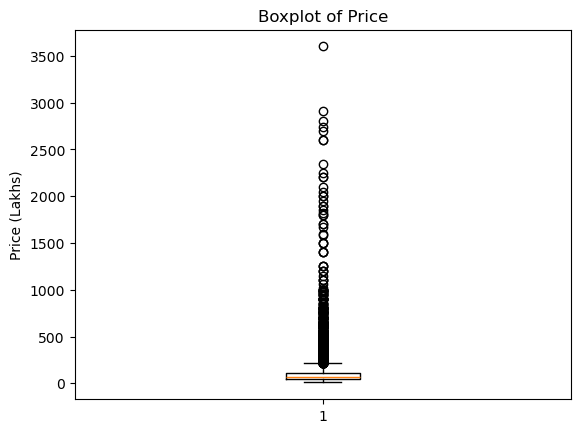

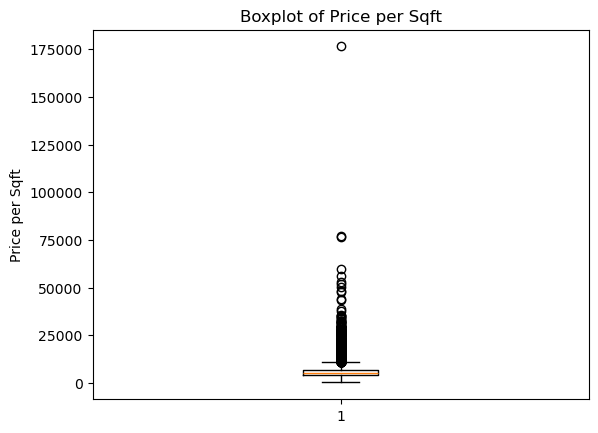

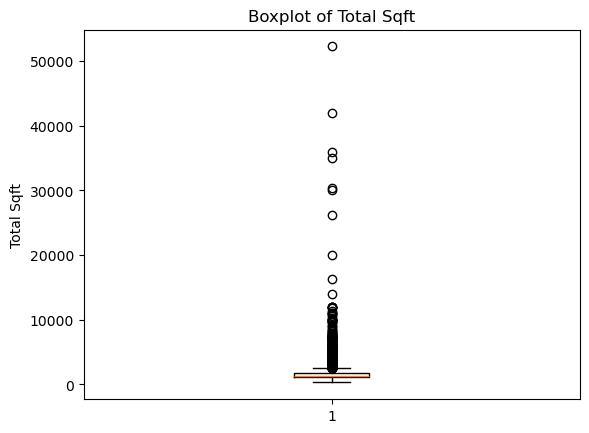

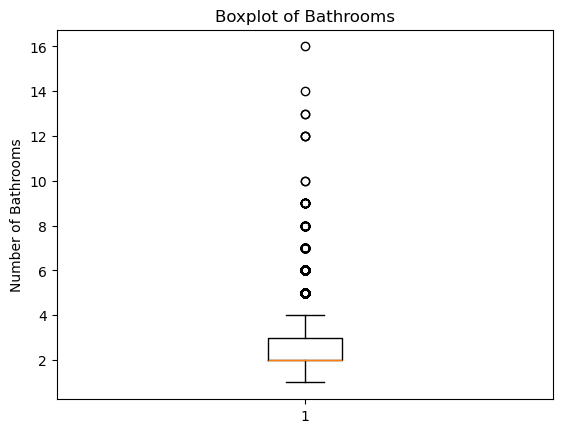

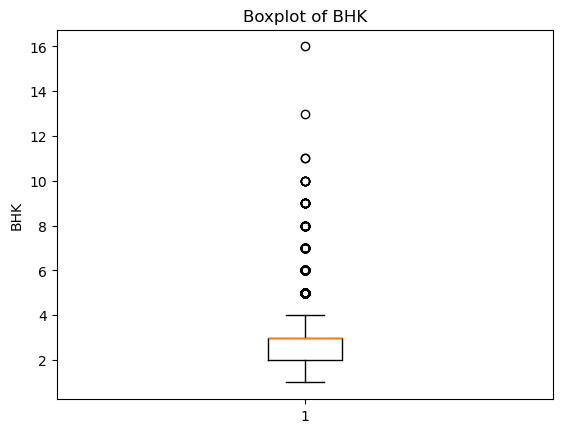

In [21]:
# ==========================
# Extra: Boxplots (Before Outlier Removal)
# ==========================
plt.boxplot(df['price'])
plt.title("Boxplot of Price")
plt.ylabel("Price (Lakhs)")
plt.show()

plt.boxplot(df['price_per_sqft'])
plt.title("Boxplot of Price per Sqft")
plt.ylabel("Price per Sqft")
plt.show()

plt.boxplot(df['total_sqft'])
plt.title("Boxplot of Total Sqft")
plt.ylabel("Total Sqft")
plt.show()

plt.boxplot(df['bath'])
plt.title("Boxplot of Bathrooms")
plt.ylabel("Number of Bathrooms")
plt.show()

plt.boxplot(df['bhk'])
plt.title("Boxplot of BHK")
plt.ylabel("BHK")
plt.show()


In [22]:
# ==========================
# Task 7: Identify and Handle Outliers
# ==========================
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['total_sqft', 'bath', 'price', 'bhk', 'price_per_sqft']:
    df = remove_outliers(df, col)

print("Final cleaned dataset shape:", df.shape)

Final cleaned dataset shape: (10090, 7)
